#Analysing Dataset

###Importing necessary libraries

In [2]:
import matplotlib.pyplot as plt #visualisation
import pandas as pd #data manipulation, analysis and cleaning
import seaborn as sns #visualisation
import numpy as np
from collections import defaultdict

#Loading blocks

In [3]:
# LOADING BLOCKS
def load_blocks(file_path):
    blocks = [] #empty list of blocks
    cur = [] # empty list of data that i currently read
     # (current block until empty line is detected)

    with open(file_path, "r") as f:
      # open and read file in path as f
        for line in f:
          # for each line in the f file
            line = line.strip()
            #removing white space in the line,
            # as it is not organised in table
            if not line:
              # if line is empty
                if cur:
                  # if cur (cur list), is not empty
                    blocks.append(np.array(cur, dtype=np.float32))
                    # adding group of MFCC rows, it went through (as a float)
                    # to blocks

                    cur = []
                    # if current values in block is empty
                continue
                    # continue the process (line by line)
            cur.append([float(x) for x in line.split()])
            # as reading through each line and stripping it
            # add to the current block list
            # for each value split to add into list seperated

    if cur:
      # if current block list
        blocks.append(np.array(cur, dtype=np.float32))
        # adding group of MFCC rows, it went through (as a float)
        # to blocks
        print("completed block load")
    return blocks

In [4]:
train_blocks = load_blocks("Train_Arabic_Digit.txt")
  # loading the blocks for train dataset for analyst
test_blocks  = load_blocks("Test_Arabic_Digit.txt")
  # loading the blocks for test dataset for analyst

completed block load
completed block load


##Checking how the dataset is split

% of Train and Test split

In [17]:
# Calculating the split % of train and test dataset

def count_blocks(file_path):
    with open(file_path, "r") as f:
        content = f.read().strip()
    blocks = content.split("\n")  # split by blank lines
    return len(blocks)

train_blocks = count_blocks("Train_Arabic_Digit.txt")
test_blocks = count_blocks("Test_Arabic_Digit.txt")

total = train_blocks + test_blocks

train_percent = (train_blocks / total) * 100
test_percent = (test_blocks / total) * 100

print(f"Total Data: {total}")
print(f"Train Data: {train_blocks}")
print(f"Test Data: {test_blocks}")
print(f"Train: {train_percent:.2f}%")
print(f"Train Rounded %: {round(train_percent)}%")
print(f"Test: {test_percent:.2f}%")
print(f"Test Rounded %: {round(test_percent)}%")


Total Data: 359117
Train Data: 269855
Test Data: 89262
Train: 75.14%
Train Rounded %: 75%
Test: 24.86%
Test Rounded %: 25%


##Checking for any invalid data

In [81]:
def check_mfcc(blocks, name):
    invalid = []
    # empty list for bad/invalid utterances
    for i, b in enumerate(blocks):
      # as we loop through the list, checking index of the blocks
        if b.shape[1] != 13:
          # if the index of the utterance does not equal 13
            invalid.append((i, b.shape))
            # add the current utterance to the in the invalid list
    print(f"{name}: {len(invalid)} invalid utterances")
    #printing the name of the dataset, including the count of invalid utterance
      #in the invalid list
    return invalid
    # return invalid list

check_mfcc(train_blocks, "Train")
# using function to check train dataset
check_mfcc(test_blocks, "Test")
# using function to check test dataset

Train: 0 invalid utterances
Test: 0 invalid utterances


[]

##Minimum, Maximum, and Average Sequence Lengths

In [82]:
def length_stats(blocks, name):
    lengths = np.array([b.shape[0] for b in blocks])
    # each block is read, and returns lengths of each block
    print(f"\n{name} sequence lengths:")
    # title for train and test dataset
    print(f"  Array of length each block: {lengths}")
    # output of array of length for each block
    print(f"  Min: {lengths.min()}")
    # output of minimum length of block in said dataset
    print(f"  Max: {lengths.max()}")
    # output of maximum length of block in said dataset
    print(f"  Mean: {lengths.mean():.2f}")
    # output of mean length of block in said dataset
    print(f"  Std: {lengths.std():.2f}")
    # output of standard deviation length of block in said dataset
    return lengths
    # return value of lengths

train_lengths = length_stats(train_blocks, "Train")
# run funcion for train dataset
test_lengths  = length_stats(test_blocks, "Test")
# run function for test dataset


Train sequence lengths:
  Array of length each block: [38 39 45 ... 34 32 32]
  Min: 4
  Max: 93
  Mean: 39.89
  Std: 8.72

Test sequence lengths:
  Array of length each block: [28 28 34 ... 32 34 34]
  Min: 7
  Max: 83
  Mean: 39.57
  Std: 8.04


###Mean and Std Comparison

In [83]:
def mfcc_stats(blocks):
    all_frames = np.vstack(blocks)
    # stacks the arrays in blocks as all frames
    return all_frames.mean(axis=0), all_frames.std(axis=0)
    # returning the value using mean and std

train_mean, train_std = mfcc_stats(train_blocks)
# run the function for train dataset, returning values for mean and std
test_mean, test_std   = mfcc_stats(test_blocks)
# run the function for test dataset, returning values for mean and std

print("Train MFCC mean:", train_mean)
print("Train MFCC std :", train_std)
# outputs train mfcc mean and std
print("\nTest  MFCC mean:", test_mean)
print("Test  MFCC std :", test_std)
# outputs test mfcc mean and std

Train MFCC mean: [ 1.9802856  -3.0797114  -0.36043555 -1.1464967  -0.6885425  -0.6174982
 -0.28101072 -0.43159732 -0.14117728 -0.39886373 -0.2697846  -0.16666904
 -0.1443034 ]
Train MFCC std : [2.7501636  2.1278539  1.736533   1.295962   1.0715071  0.8722286
 0.72935545 0.83550876 0.64966875 0.6362679  0.6290572  0.5918004
 0.53944063]

Test  MFCC mean: [ 2.1935332  -3.2257202  -0.44962332 -1.2559838  -0.76472074 -0.6777276
 -0.3345634  -0.5202343  -0.13617748 -0.44942912 -0.33901262 -0.2566464
 -0.14912799]
Test  MFCC std : [2.7773356  1.7966032  1.6606858  1.3097196  1.0625945  0.90920776
 0.72883135 0.8290366  0.6609481  0.6158757  0.64946043 0.59452766
 0.5177897 ]


### Line Plot to Visualise Comparison

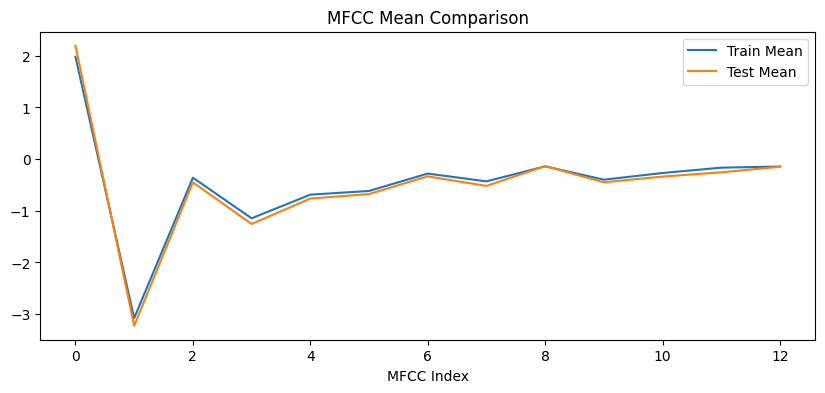

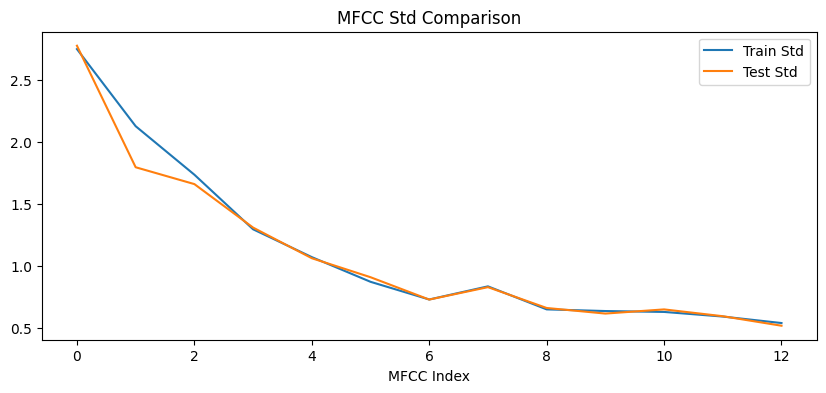

In [84]:
plt.figure(figsize=(10, 4))
# line plot for mean comparison between each dataset (test and train)
plt.plot(train_mean, label="Train Mean")
plt.plot(test_mean, label="Test Mean")
plt.title("MFCC Mean Comparison")
plt.xlabel("MFCC Index")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
# line plot for std comparison between each dataset (test and train)
plt.plot(train_std, label="Train Std")
plt.plot(test_std, label="Test Std")
plt.title("MFCC Std Comparison")
plt.xlabel("MFCC Index")
plt.legend()
plt.show()

##Distribution of the number of MFCC frames per utterance

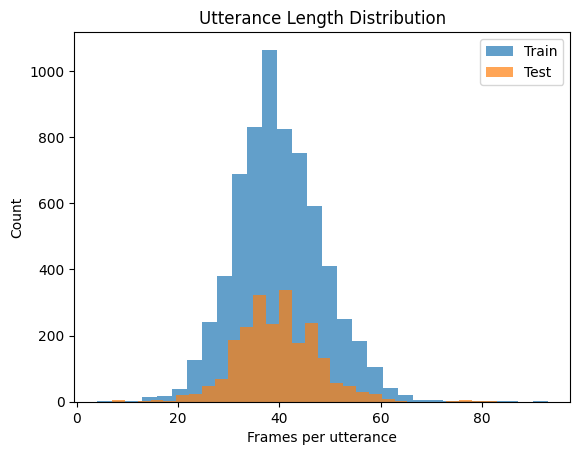

In [85]:
plt.hist(train_lengths, bins=30, alpha=0.7, label="Train")
# creating histogram for train dataset
plt.hist(test_lengths, bins=30, alpha=0.7, label="Test")
# creating histogram for test dataset
plt.xlabel("Frames per utterance")
plt.ylabel("Count")
plt.title("Utterance Length Distribution")
plt.legend()
plt.show()

##Comparison of sequence lengths and MFCC statistics between male and female speakers

### seperating male and female speakers in both datasets

In [86]:
train_male_blocks, train_female_blocks = train_blocks[:330], train_blocks[331:660]
#seperation of male and female speakers in train dataset
test_male_blocks, test_female_blocks = test_blocks[:110], test_blocks[110:220]
#seperation of male and female speakers in test dataset

In [87]:
# get mean MFCC per block for male and female speakers
mean_male_mfcc = np.array([np.mean(b, axis=0) for b in train_male_blocks + test_male_blocks])
mean_female_mfcc = np.array([np.mean(b, axis=0) for b in train_female_blocks + test_female_blocks])

# average across all blocks for male and female speakers
mean_male_avg = np.mean(mean_male_mfcc, axis=0)
mean_female_avg = np.mean(mean_female_mfcc, axis=0)

In [88]:
# get std MFCC per block for male and female speakers
std_male_mfcc = np.array([np.std(b, axis=0) for b in train_male_blocks + test_male_blocks])
std_female_mfcc = np.array([np.std(b, axis=0) for b in train_female_blocks + test_female_blocks])

# average across all blocks for male and female speakers
std_male_avg = np.mean(std_male_mfcc, axis=0)
std_female_avg = np.mean(std_female_mfcc, axis=0)

### Line plot

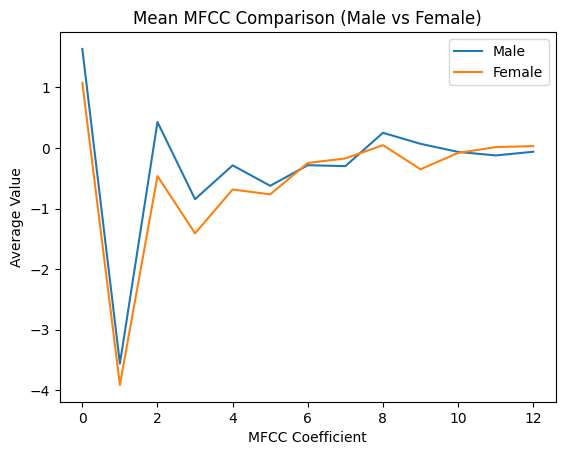

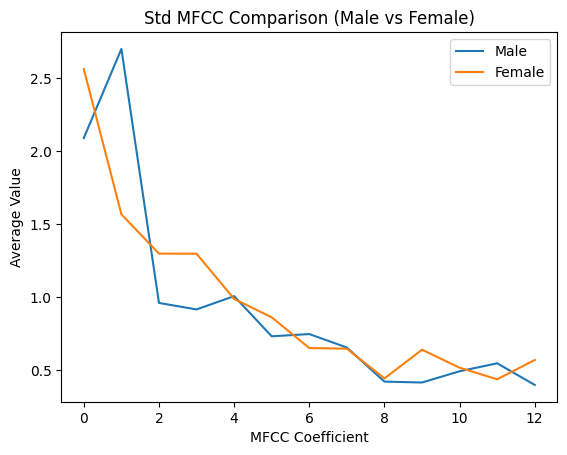

In [89]:
# line plot for visual comparison (mean)
plt.plot(mean_male_avg, label="Male")
plt.plot(mean_female_avg, label="Female")

plt.xlabel("MFCC Coefficient")
plt.ylabel("Average Value")
plt.title("Mean MFCC Comparison (Male vs Female)")
plt.legend()

plt.show()

# line plot for visual comparison (std)
plt.plot(std_male_avg, label="Male")
plt.plot(std_female_avg, label="Female")

plt.xlabel("MFCC Coefficient")
plt.ylabel("Average Value")
plt.title("Std MFCC Comparison (Male vs Female)")
plt.legend()

plt.show()

### Heat map

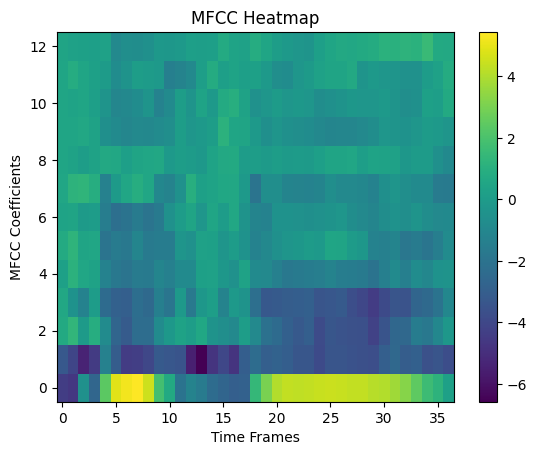

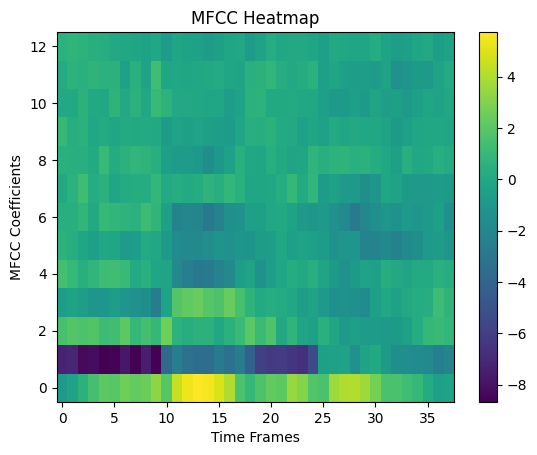

In [90]:
# convert one block to array
mfcc_f = np.array(train_female_blocks[0])
# convert array to image

plt.imshow(mfcc_f.T, aspect='auto', origin='lower')
# show image
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()

mfcc_m = np.array(train_male_blocks[0])
# convert array to image
plt.imshow(mfcc_m.T, aspect='auto', origin='lower')
# show image
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()

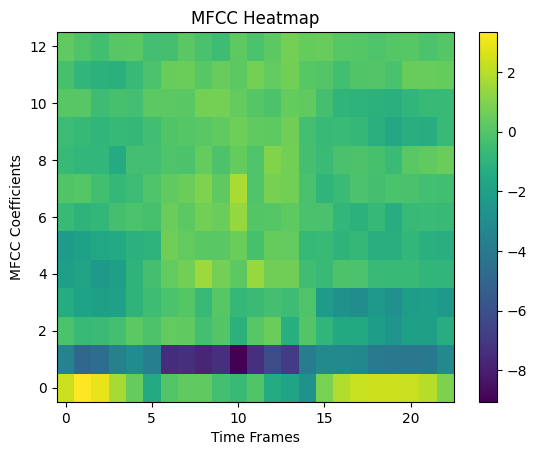

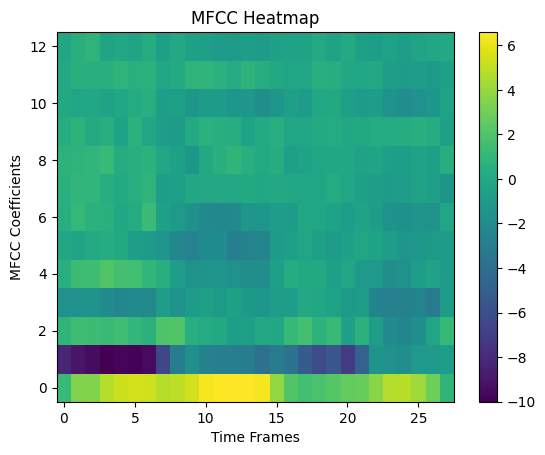

In [91]:
# convert one block to array
mfcc_ftest = np.array(test_female_blocks[0])
# convert array to image

plt.imshow(mfcc_ftest.T, aspect='auto', origin='lower')
# show image
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()

mfcc_mtest = np.array(test_male_blocks[0])
# convert array to image
plt.imshow(mfcc_mtest.T, aspect='auto', origin='lower')
# show image
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.title("MFCC Heatmap")
plt.colorbar()
plt.show()

In [ ]:
def assign_labels(n_blocks, blocks_per_digit):
    return np.arange(n_blocks) // blocks_per_digit

train_labels = assign_labels(len(train_blocks), 660)

In [ ]:
def utterance_energy(block):
    return np.mean(np.abs(block))

train_energy = np.array([utterance_energy(b) for b in train_blocks])

plt.hist(train_energy, bins=50)
plt.xlabel("Average MFCC magnitude")
plt.ylabel("Count")
plt.title("Utterance Energy Distribution")
plt.show()

In [ ]:
utterance_var = np.array([b.var() for b in train_blocks])

plt.hist(utterance_var, bins=50)
plt.xlabel("MFCC Variance")
plt.ylabel("Count")
plt.title("Utterance-Level MFCC Variance")
plt.show()